In [12]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(
    n_samples=50000,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9694666666666667


In [14]:
from sklearn.ensemble import BaggingClassifier

bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,      # number of trees
    max_samples=0.8,      # each model sees 80% data
    bootstrap=True        # sampling with replacement
)

bag.fit(X_train, y_train)

y_pred_bag = bag.predict(X_test)
print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bag))

Bagging Accuracy: 0.9797333333333333


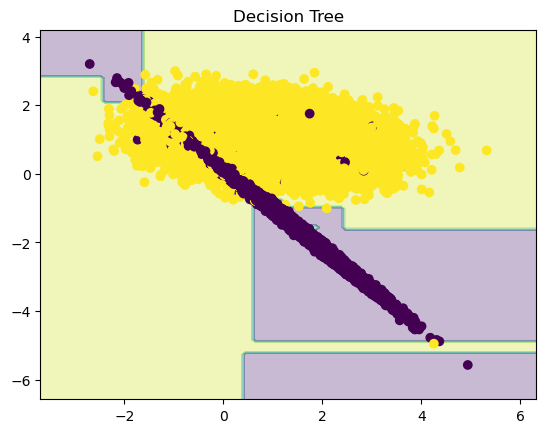

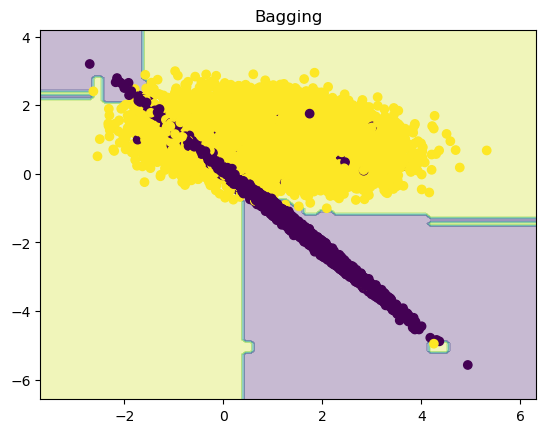

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def plot_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title(title)
    plt.show()

plot_boundary(dt, X, y, "Decision Tree")
plot_boundary(bag, X, y, "Bagging")

In [18]:
import pandas as pd

In [19]:
df=pd.read_csv("Iris.csv")

In [21]:
df.sample(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
74,75,6.4,2.9,4.3,1.3,Iris-versicolor
19,20,5.1,3.8,1.5,0.3,Iris-setosa
73,74,6.1,2.8,4.7,1.2,Iris-versicolor
98,99,5.1,2.5,3.0,1.1,Iris-versicolor
104,105,6.5,3.0,5.8,2.2,Iris-virginica


In [24]:
df=df.iloc[:,1:]

In [25]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [26]:
from sklearn.preprocessing import LabelEncoder

In [29]:
encoder= LabelEncoder()

In [30]:
df['Species']= encoder.fit_transform(df["Species"])

In [31]:
df = df[df['Species'] != 0][['SepalWidthCm','PetalLengthCm','Species']]

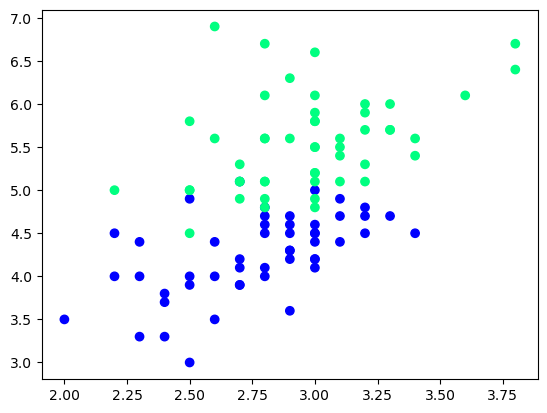

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'],c=df['Species'],cmap='winter')

In [35]:
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [36]:
df_train

,SepalWidthCm,PetalLengthCm,Species
86,3.1,4.7,1
94,2.7,4.2,1
79,2.6,3.5,1
138,3.0,4.8,2
78,2.9,4.5,1
107,2.9,6.3,2
103,2.9,5.6,2
77,3.0,5.0,1
95,3.0,4.2,1
53,2.3,4.0,1


In [38]:
df_val

,SepalWidthCm,PetalLengthCm,Species
119,2.2,5.0,2
108,2.5,5.8,2
145,3.0,5.2,2
81,2.4,3.7,1
67,2.7,4.1,1


In [39]:
df_test

,SepalWidthCm,PetalLengthCm,Species
122,2.8,6.7,2
136,3.4,5.6,2
92,2.6,4.0,1
88,3.0,4.1,1
142,2.7,5.1,2


In [40]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [41]:
y_test

array([2, 2, 2, 1, 1])

In [70]:
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
77,3.0,5.0,1
103,2.9,5.6,2
77,3.0,5.0,1
86,3.1,4.7,1
103,2.9,5.6,2
138,3.0,4.8,2
77,3.0,5.0,1
103,2.9,5.6,2


In [71]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [72]:
dt_bag1 = DecisionTreeClassifier()

In [73]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))
    

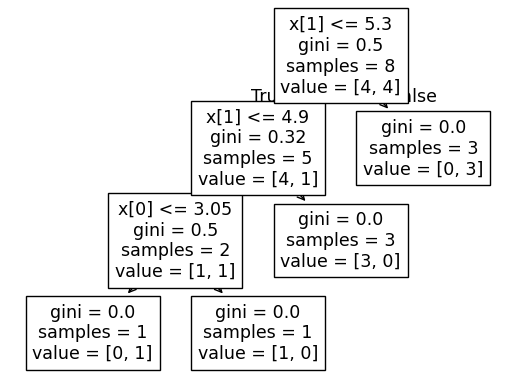

E:\Python\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
E:\Python\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.2


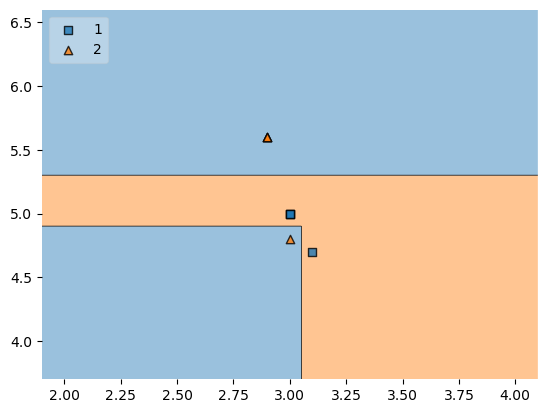

In [74]:
evaluate(dt_bag1,X,y)

In [75]:
##Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
103,2.9,5.6,2
95,3.0,4.2,1
86,3.1,4.7,1
138,3.0,4.8,2
77,3.0,5.0,1
77,3.0,5.0,1
103,2.9,5.6,2
53,2.3,4.0,1


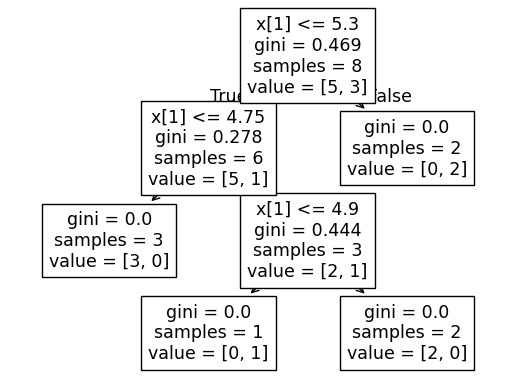

E:\Python\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
E:\Python\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.6


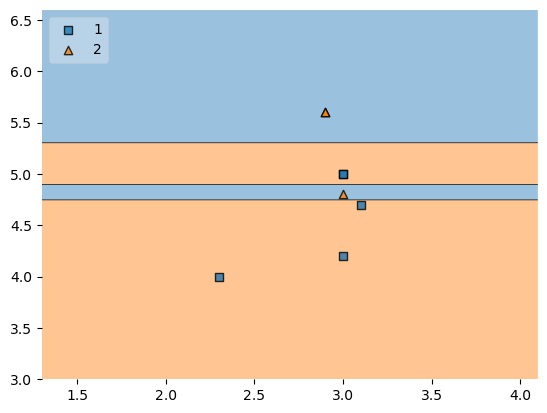

In [76]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [77]:
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
79,2.6,3.5,1
53,2.3,4.0,1
107,2.9,6.3,2
53,2.3,4.0,1
79,2.6,3.5,1
77,3.0,5.0,1
94,2.7,4.2,1
53,2.3,4.0,1


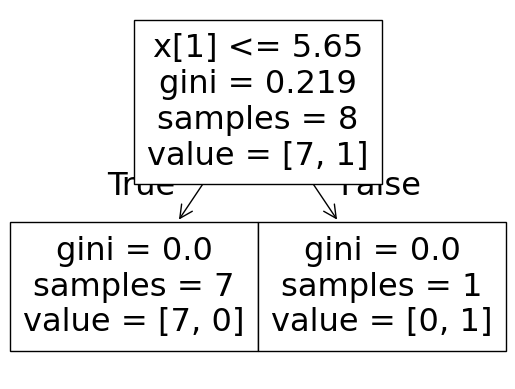

E:\Python\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
E:\Python\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.6


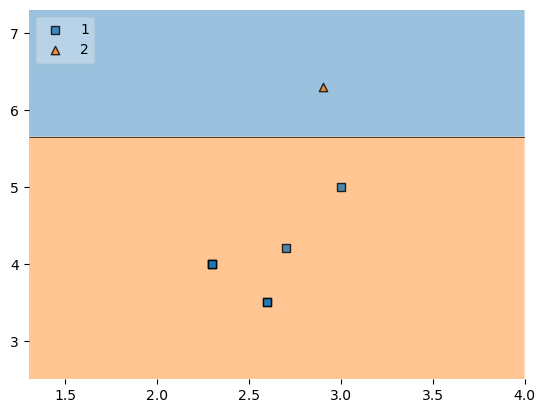

In [78]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

## Predict

In [79]:
df_test

,SepalWidthCm,PetalLengthCm,Species
122,2.8,6.7,2
136,3.4,5.6,2
92,2.6,4.0,1
88,3.0,4.1,1
142,2.7,5.1,2


In [80]:
print("Predictor 1",dt_bag1.predict(np.array([3.0,4.1]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([3.0,4.1]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([3.0,4.1]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [1]
Predictor 3 [1]


E:\Python\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
E:\Python\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
E:\Python\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
